In [1]:
!pip install bitsandbytes

# S15 – PEFT / LoRA: компактная адаптация LLM под задачу классификации

В этом ноутбуке делаем следующий шаг после **prompt engineering**:  
не просто подбираем формулировку запроса, а **компактно адаптируем instruct-LLM под свою задачу** с помощью **PEFT / LoRA**.

Главная идея такая:

1. берём небольшую instruct-модель;
2. подготавливаем короткий размеченный датасет;
3. переводим примеры в **instruction-формат**;
4. замораживаем большую часть весов модели;
5. обучаем только небольшой набор дополнительных параметров LoRA;
6. сравниваем поведение модели **до** и **после** адаптации.

Важно: это **учебный pipeline**.  
Мы сознательно берём **небольшой датасет**, **компактную модель** и **короткое обучение**,  
чтобы увидеть всю инженерную цепочку целиком, а не бороться с инфраструктурой.

> Цель – не получить «боевое» качество, а понять, **как выглядит практическая адаптация LLM через PEFT / LoRA**.

## 0. План

К концу ноутбука надо уметь:

1. Подготовить небольшой размеченный датасет для instruction-style обучения LLM.
2. Разбить данные на `train / validation / test`.
3. Преобразовать примеры в формат диалога `system → user → assistant`.
4. Подготовить токены и маску `labels`, чтобы модель училась только на ответе ассистента.
5. Загрузить базовую instruct-LLM и перевести её в режим компактной адаптации через LoRA.
6. Настроить `TrainingArguments` и запустить LoRA fine-tuning.
7. Сравнить качество модели до и после адаптации.
8. Проверить модель на новых текстах и разобрать типичные ошибки.

## 1. Импорты и общие настройки

Ниже подключаем библиотеки, фиксируем `seed`, выбираем устройство и настраиваем удобный вывод.

Для снижения требований к памяти предусмотрена **опциональная 4-bit загрузка** через `bitsandbytes`, если пакет доступен и есть GPU.  
Если `bitsandbytes` недоступен, ноутбук всё равно может работать в обычном режиме.

> Предполагается, что в окружении уже доступны `torch`, `transformers`, `datasets`, `peft`, `accelerate`, `scikit-learn`, `pandas`, `numpy` и `matplotlib`.  
> Пакет `bitsandbytes` желателен, но не обязателен.

In [2]:
# Базовые библиотеки для воспроизводимости, анализа и адаптации LLM.
import os
import random
import re
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    default_data_collator,
)

from peft import LoraConfig, TaskType, get_peft_model

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    from transformers import BitsAndBytesConfig
    BNB_AVAILABLE = True
except Exception:
    BitsAndBytesConfig = None
    BNB_AVAILABLE = False

try:
    import bitsandbytes  # noqa: F401  — проверяем, что пакет реально установлен
    from peft import prepare_model_for_kbit_training
    KBIT_PREPARE_AVAILABLE = True
except Exception:
    prepare_model_for_kbit_training = None
    KBIT_PREPARE_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("bitsandbytes available:", BNB_AVAILABLE)
print("prepare_model_for_kbit_training available:", KBIT_PREPARE_AVAILABLE)

Torch: 2.10.0+cu128
CUDA available: True
bitsandbytes available: True
prepare_model_for_kbit_training available: True


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)

Устройство: cuda


## 2. Учебный датасет и постановка задачи

Как и в предыдущем ноутбуке, используем **короткие пользовательские сообщения** из условного issue-трекера или системы обратной связи.

Сохраняем те же 4 класса:

- `bug` – ошибка, сбой, падение, некорректная работа;
- `feature` – просьба добавить функцию или улучшение;
- `question` – вопрос, уточнение, запрос информации;
- `praise` – положительный отзыв без просьбы что-то изменить.

Но теперь нам нужен **не просто набор для инференса**, а **небольшой размеченный датасет для обучения**.  
Поэтому сделаем его чуть больше, чтобы хватило на `train / validation / test`.

In [4]:
ALLOWED_LABELS = ["bug", "feature", "question", "praise"]

label_descriptions = {
    "bug": "сообщение об ошибке, сбое, падении, зависании или некорректной работе",
    "feature": "предложение добавить функцию, фильтр, настройку или иное улучшение",
    "question": "вопрос, просьба объяснить, уточнение или запрос информации",
    "praise": "положительный отзыв или благодарность без запроса на изменение",
}

samples: List[Dict[str, str]] = [
    # bug
    {"text": "После входа в аккаунт приложение закрывается без сообщения об ошибке.", "label": "bug"},
    {"text": "Форма оплаты зависает после нажатия на кнопку подтверждения.", "label": "bug"},
    {"text": "В мобильной версии отчёт иногда открывается пустым экраном.", "label": "bug"},
    {"text": "После обновления не сохраняются изменения в карточке клиента.", "label": "bug"},
    {"text": "Экспорт в Excel падает, если в таблице больше тысячи строк.", "label": "bug"},
    {"text": "Страница настроек долго грузится и затем показывает ошибку 500.", "label": "bug"},
    {"text": "Уведомления отмечаются как прочитанные сами по себе, хотя я их не открывал.", "label": "bug"},
    {"text": "При попытке сменить пароль система пишет, что токен недействителен.", "label": "bug"},
    {"text": "После нажатия на кнопку печати интерфейс зависает на несколько секунд.", "label": "bug"},
    {"text": "Иногда карточка заказа дублируется после обычного обновления страницы.", "label": "bug"},

    # feature
    {"text": "Добавьте, пожалуйста, тёмную тему для панели управления.", "label": "feature"},
    {"text": "Было бы удобно сохранять часто используемые фильтры поиска.", "label": "feature"},
    {"text": "Сделайте выгрузку отчётов сразу в PDF и Excel.", "label": "feature"},
    {"text": "Хочется видеть историю изменений по каждой заявке.", "label": "feature"},
    {"text": "Добавьте быстрые клавиши для перехода между вкладками.", "label": "feature"},
    {"text": "Можно ли сделать отдельную роль только для просмотра аналитики?", "label": "feature"},
    {"text": "Нужен фильтр по периоду и по ответственному сотруднику.", "label": "feature"},
    {"text": "Хорошо бы настроить автоматическую отправку отчёта раз в неделю.", "label": "feature"},
    {"text": "Добавьте возможность закреплять важные проекты сверху списка.", "label": "feature"},
    {"text": "Стоит реализовать пакетное редактирование статусов у нескольких задач.", "label": "feature"},

    # question
    {"text": "Подскажите, где можно скачать закрывающие документы за прошлый месяц?", "label": "question"},
    {"text": "Почему уведомления приходят только на почту, а в интерфейсе их не видно?", "label": "question"},
    {"text": "Какой формат файла нужен для массовой загрузки пользователей?", "label": "question"},
    {"text": "Где в системе посмотреть журнал действий оператора?", "label": "question"},
    {"text": "Можно ли ограничить доступ к проекту только одной команде?", "label": "question"},
    {"text": "Есть ли в сервисе API для получения списка заказов?", "label": "question"},
    {"text": "Как восстановить удалённую запись, если её убрали по ошибке?", "label": "question"},
    {"text": "Сколько времени хранятся архивные отчёты в системе?", "label": "question"},
    {"text": "Почему поле ИНН не заполняется автоматически из справочника?", "label": "question"},
    {"text": "Где переключается часовой пояс для отчётов и уведомлений?", "label": "question"},

    # praise
    {"text": "Спасибо, новый интерфейс стал заметно понятнее и быстрее.", "label": "praise"},
    {"text": "Очень удобно, что теперь все отчёты собраны в одном разделе.", "label": "praise"},
    {"text": "Отличное обновление, стало проще работать с большими таблицами.", "label": "praise"},
    {"text": "Спасибо команде, новая форма заявки выглядит аккуратно и логично.", "label": "praise"},
    {"text": "Классно, что экспорт теперь работает почти мгновенно.", "label": "praise"},
    {"text": "Наконец-то поиск стал действительно быстрым, это очень помогает.", "label": "praise"},
    {"text": "Очень понравилось, как теперь устроена навигация по разделам.", "label": "praise"},
    {"text": "Спасибо, новая страница аналитики выглядит намного чище.", "label": "praise"},
    {"text": "Хорошая доработка: стало меньше лишних кликов при работе с заказами.", "label": "praise"},
    {"text": "Отлично, что добавили подсказки в полях формы – это удобно.", "label": "praise"},
]

df = pd.DataFrame(samples)
display(df.head(12))
print("Размер датасета:", len(df))
print("Распределение классов:")
display(df["label"].value_counts())

,text,label
0,После входа в аккаунт приложение закрывается без сообщения об ошибке.,bug
1,Форма оплаты зависает после нажатия на кнопку подтверждения.,bug
2,В мобильной версии отчёт иногда открывается пустым экраном.,bug
3,После обновления не сохраняются изменения в карточке клиента.,bug
4,"Экспорт в Excel падает, если в таблице больше тысячи строк.",bug
5,Страница настроек долго грузится и затем показывает ошибку 500.,bug
6,"Уведомления отмечаются как прочитанные сами по себе, хотя я их не открывал.",bug
7,"При попытке сменить пароль система пишет, что токен недействителен.",bug
8,После нажатия на кнопку печати интерфейс зависает на несколько секунд.,bug
9,Иногда карточка заказа дублируется после обычного обновления страницы.,bug


Размер датасета: 40
Распределение классов:


,count
label,
bug,10
feature,10
question,10
praise,10


## 3. Разбиение на `train / validation / test`

Используем двухэтапное стратифицированное разбиение:

1. сначала отделяем тестовую выборку;
2. затем из оставшейся части выделяем валидацию.

Параметр `stratify` нужен, чтобы **сохранять баланс классов** в каждой подвыборке.

In [5]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,  # 0.25 от 80% = 20% от исходного датасета
    random_state=42,
    stratify=train_val_df["label"],
)

print("Размеры выборок:")
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Размеры выборок:
train: 24
validation: 8
test: 8

Распределение классов в train:


,count
label,
question,6
feature,6
praise,6
bug,6


Распределение классов в validation:


,count
label,
bug,2
question,2
feature,2
praise,2


Распределение классов в test:


,count
label,
praise,2
question,2
bug,2
feature,2


## 4. Переход к `datasets.DatasetDict`

Для работы с `Trainer` удобно перевести датафреймы в формат `datasets.DatasetDict`.

Это даёт нам:

- единый интерфейс для `train / validation / test`;
- удобный `map(...)` для подготовки токенов;
- совместимость с `Trainer`.

In [6]:
dataset_dict = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
        "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
        "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
    }
)

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 24
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 8
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 8
    })
})

In [7]:
# Посмотрим на несколько примеров.
display(dataset_dict["train"].to_pandas().head())

,text,label
0,"Подскажите, где можно скачать закрывающие документы за прошлый месяц?",question
1,Хорошо бы настроить автоматическую отправку отчёта раз в неделю.,feature
2,Было бы удобно сохранять часто используемые фильтры поиска.,feature
3,"Наконец-то поиск стал действительно быстрым, это очень помогает.",praise
4,Где в системе посмотреть журнал действий оператора?,question


## 5. Подготовка данных в instruction-формате

Теперь превращаем обычную задачу классификации в **instruction-style сценарий для LLM**.

Для каждого примера строим такой диалог:

- `system`: описывает роль модели и доступные классы;
- `user`: содержит инструкцию и конкретный текст;
- `assistant`: возвращает только метку класса.

Именно этот последний ответ (`assistant`) модель и должна научиться генерировать.

Важно: при обучении мы хотим штрафовать модель **только за ответ ассистента**,  
а не за повторение всего prompt-а. Поэтому позже отдельно построим `labels`,  
в которых токены prompt-а будут замаскированы значением `-100`.

In [8]:
SYSTEM_PROMPT = (
    "Ты помогаешь классифицировать короткие пользовательские сообщения. "
    "Нужно выбрать ровно один класс из набора: bug, feature, question, praise."
)


def build_user_prompt(text: str) -> str:
    return (
        "Классифицируй сообщение ровно по одному классу из списка: "
        "bug, feature, question, praise.\n"
        "Опирайся только на смысл сообщения.\n\n"
        "Правила:\n"
        "- bug: ошибка, сбой, падение, зависание или некорректная работа;\n"
        "- feature: просьба добавить функцию, настройку, фильтр или улучшение;\n"
        "- question: вопрос, уточнение, просьба объяснить или запрос информации;\n"
        "- praise: положительный отзыв или благодарность без просьбы что-то изменить.\n\n"
        f"Сообщение: {text}\n\n"
        "Ответь только названием класса."
    )


def make_messages(text: str, label: Optional[str] = None) -> List[Dict[str, str]]:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(text)},
    ]
    if label is not None:
        messages.append({"role": "assistant", "content": label})
    return messages

In [9]:
# Посмотрим, как выглядит один учебный пример в терминах сообщений.
example_messages = make_messages(dataset_dict["train"][0]["text"], dataset_dict["train"][0]["label"])
example_messages

[{'role': 'system',
  'content': 'Ты помогаешь классифицировать короткие пользовательские сообщения. Нужно выбрать ровно один класс из набора: bug, feature, question, praise.'},
 {'role': 'user',
  'content': 'Классифицируй сообщение ровно по одному классу из списка: bug, feature, question, praise.\nОпирайся только на смысл сообщения.\n\nПравила:\n- bug: ошибка, сбой, падение, зависание или некорректная работа;\n- feature: просьба добавить функцию, настройку, фильтр или улучшение;\n- question: вопрос, уточнение, просьба объяснить или запрос информации;\n- praise: положительный отзыв или благодарность без просьбы что-то изменить.\n\nСообщение: Подскажите, где можно скачать закрывающие документы за прошлый месяц?\n\nОтветь только названием класса.'},
 {'role': 'assistant', 'content': 'question'}]

## 6. Токенизатор и подготовка входов

Теперь загружаем токенизатор и определяем функцию токенизации.

Используем ту же компактную instruct-модель, что и в предыдущем ноутбуке,  
чтобы сохранить преемственность между **prompt-only** и **LoRA-adaptation** сценариями.

Логика подготовки такая:

1. строим **полный диалог** (`system + user + assistant`);
2. отдельно строим **только prompt** (`system + user`);
3. токенизируем оба варианта;
4. создаём `labels`, где токены prompt-а заменены на `-100`;
5. модель учится предсказывать только токены ответа ассистента.

Это и есть минимальный вариант **instruction tuning** для causal LM.

In [10]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_LENGTH = 384

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None and tokenizer.eos_token is not None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded for:", MODEL_NAME)
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer loaded for: Qwen/Qwen2.5-0.5B-Instruct
pad_token_id: 151643
eos_token_id: 151645


In [11]:
def render_chat(messages: List[Dict[str, str]], add_generation_prompt: bool = False) -> str:
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
    )


def tokenize_instruction_example(example: Dict[str, str]) -> Dict[str, Any]:
    full_messages = make_messages(example["text"], example["label"])
    prompt_messages = make_messages(example["text"], label=None)

    full_text = render_chat(full_messages, add_generation_prompt=False)
    prompt_text = render_chat(prompt_messages, add_generation_prompt=True)

    full_tokens = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        add_special_tokens=False,
    )

    prompt_tokens = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        add_special_tokens=False,
    )

    input_ids = full_tokens["input_ids"]
    attention_mask = full_tokens["attention_mask"]
    labels = input_ids.copy()

    prompt_len = int(sum(prompt_tokens["attention_mask"]))

    labels = [
        token if attn == 1 else -100
        for token, attn in zip(labels, attention_mask)
    ]

    for i in range(min(prompt_len, len(labels))):
        labels[i] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "prompt_text": prompt_text,
        "full_text": full_text,
        "target_label": example["label"],
    }


formatted_dataset = dataset_dict.map(tokenize_instruction_example)

formatted_dataset

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask', 'labels', 'prompt_text', 'full_text', 'target_label'],
        num_rows: 24
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask', 'labels', 'prompt_text', 'full_text', 'target_label'],
        num_rows: 8
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask', 'labels', 'prompt_text', 'full_text', 'target_label'],
        num_rows: 8
    })
})

In [12]:
# Посмотрим на один пример после подготовки.
sample_row = formatted_dataset["train"][0]

print("TARGET LABEL:", sample_row["target_label"])
print("\nPROMPT TEXT:\n")
print(sample_row["prompt_text"][:1200])

assistant_token_ids = [token_id for token_id in sample_row["labels"] if token_id != -100]
print("\nASSISTANT TARGET TOKENS DECODING:")
print(tokenizer.decode(assistant_token_ids, skip_special_tokens=True))

TARGET LABEL: question

PROMPT TEXT:

<|im_start|>system
Ты помогаешь классифицировать короткие пользовательские сообщения. Нужно выбрать ровно один класс из набора: bug, feature, question, praise.<|im_end|>
<|im_start|>user
Классифицируй сообщение ровно по одному классу из списка: bug, feature, question, praise.
Опирайся только на смысл сообщения.

Правила:
- bug: ошибка, сбой, падение, зависание или некорректная работа;
- feature: просьба добавить функцию, настройку, фильтр или улучшение;
- question: вопрос, уточнение, просьба объяснить или запрос информации;
- praise: положительный отзыв или благодарность без просьбы что-то изменить.

Сообщение: Подскажите, где можно скачать закрывающие документы за прошлый месяц?

Ответь только названием класса.<|im_end|>
<|im_start|>assistant


ASSISTANT TARGET TOKENS DECODING:
question



## 7. Базовая модель и стратегия компактной адаптации

Теперь загружаем базовую instruct-LLM.

Мы **не** будем дообучать все веса модели. Вместо этого:

- оставим базовую модель почти полностью замороженной;
- добавим небольшие LoRA-адаптеры в часть линейных слоёв;
- будем обучать только их.

Такой подход и называется **parameter-efficient fine-tuning**.

Для GPU-сценария дополнительно поддерживаем **опциональную 4-bit загрузку**.  
Если модель квантизована, перед обучением её полезно подготовить функцией `prepare_model_for_kbit_training`.

In [13]:
def load_base_model(model_name: str) -> Tuple[AutoModelForCausalLM, str]:
    load_mode = "full"

    model_kwargs: Dict[str, Any] = {"trust_remote_code": True}

    if DEVICE == "cuda":
        model_kwargs["device_map"] = "auto"
        model_kwargs["dtype"] = torch.float16
    else:
        model_kwargs["dtype"] = torch.float32

    if DEVICE == "cuda" and BNB_AVAILABLE and BitsAndBytesConfig is not None:
        try:
            model_kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
            )
            load_mode = "4-bit"
        except Exception as e:
            print("Не удалось включить 4-bit режим, продолжаем без него.")
            print("Причина:", repr(e))
            model_kwargs.pop("quantization_config", None)
            load_mode = "full"

    model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)

    if getattr(model.config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    if getattr(model.generation_config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.generation_config.pad_token_id = tokenizer.pad_token_id

    model.config.use_cache = False
    return model, load_mode


base_model, load_mode = load_base_model(MODEL_NAME)
print("Модель загружена:", MODEL_NAME)
print("Режим загрузки:", load_mode)

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Модель загружена: Qwen/Qwen2.5-0.5B-Instruct
Режим загрузки: 4-bit


## 8. Конфигурация LoRA / PEFT

Теперь определяем, **куда именно** будем вставлять LoRA-адаптеры.

Обычно в трансформерах LoRA добавляют в проекции attention и иногда в MLP-слои.  
Для учебного сценария попробуем автоматически найти типовые имена модулей:

- `q_proj`, `k_proj`, `v_proj`, `o_proj`
- `gate_proj`, `up_proj`, `down_proj`

После этого создадим `LoraConfig` и обернём базовую модель через `get_peft_model(...)`.

Отдельно посмотрим, **какая доля параметров** остаётся обучаемой.

In [14]:
def infer_lora_target_modules(model: torch.nn.Module) -> List[str]:
    preferred_names = {
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    }

    found = set()
    for module_name, _ in model.named_modules():
        short_name = module_name.split(".")[-1]
        if short_name in preferred_names:
            found.add(short_name)

    if found:
        return sorted(found)

    # Фолбэк для некоторых других архитектур.
    return ["q_proj", "v_proj"]


target_modules = infer_lora_target_modules(base_model)
print("LoRA target modules:", target_modules)

LoRA target modules: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']


In [15]:
if load_mode == "4-bit" and KBIT_PREPARE_AVAILABLE and prepare_model_for_kbit_training is not None:
    base_model = prepare_model_for_kbit_training(base_model)

if DEVICE == "cuda" and hasattr(base_model, "gradient_checkpointing_enable"):
    try:
        base_model.gradient_checkpointing_enable()
    except Exception:
        pass

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=target_modules,
)

model = get_peft_model(base_model, lora_config)

if hasattr(model, "print_trainable_parameters"):
    model.print_trainable_parameters()
else:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {trainable_params:,}")
    print(f"All params: {total_params:,}")
    print(f"Trainable ratio: {100 * trainable_params / total_params:.4f}%")

trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826


## 9. Параметры обучения

Для учебного примера выбираем достаточно мягкую конфигурацию:

- небольшой batch size;
- несколько эпох;
- умеренный learning rate;
- оценка на каждой эпохе;
- без внешних логгеров.

На CPU обучение может быть долгим.  
На GPU – заметно быстрее, особенно при 4-bit загрузке и небольшой модели.

In [16]:
# Оставляем только тензорные поля, нужные Trainer.
keep_columns = {"input_ids", "attention_mask", "labels"}

train_columns_to_remove = [c for c in formatted_dataset["train"].column_names if c not in keep_columns]
val_columns_to_remove = [c for c in formatted_dataset["validation"].column_names if c not in keep_columns]
test_columns_to_remove = [c for c in formatted_dataset["test"].column_names if c not in keep_columns]

train_dataset = formatted_dataset["train"].remove_columns(train_columns_to_remove)
val_dataset = formatted_dataset["validation"].remove_columns(val_columns_to_remove)
test_dataset = formatted_dataset["test"].remove_columns(test_columns_to_remove)

print(train_dataset)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 24
})


In [17]:
def build_training_arguments(output_dir: str = "./s15_lora_output") -> TrainingArguments:
    common_kwargs = dict(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=4,
        learning_rate=2e-4,
        weight_decay=0.0,
        logging_steps=1,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        fp16=(DEVICE == "cuda"),
    )

    try:
        return TrainingArguments(
            eval_strategy="epoch",
            **common_kwargs,
        )
    except TypeError:
        return TrainingArguments(
            evaluation_strategy="epoch",
            **common_kwargs,
        )


training_args = build_training_arguments()
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

## 10. Базовый инференс до адаптации

Перед обучением полезно зафиксировать baseline:  
как ведёт себя **исходная** instruct-модель на нашей задаче без LoRA-адаптации.

Используем тот же принцип, что и в предыдущем ноутбуке:  
даём prompt и просим вернуть **только название класса**.

> **Заметка о порядке ячеек.**  
> На первый взгляд может показаться странным, что baseline замеряется здесь –  
> уже после того, как `get_peft_model(...)` обернул базовую модель в секции 8.  
> Это безопасно, потому что LoRA инициализируется с **нулевой матрицей B**:  
> `ΔW = A · B = 0` в самом начале, и модель ведёт себя в точности как без адаптера.  
> Важно: **эти две ячейки нужно запускать строго до `trainer.train()`**;  
> если перезапустить их после обучения – `base_model` уже будет содержать обученные LoRA-веса.

In [18]:
def get_model_device(model_obj: torch.nn.Module) -> torch.device:
    if hasattr(model_obj, "device"):
        try:
            return model_obj.device
        except Exception:
            pass
    return next(model_obj.parameters()).device


def parse_label(raw_text: str) -> Optional[str]:
    normalized = raw_text.strip().lower()

    if normalized in ALLOWED_LABELS:
        return normalized

    for label in ALLOWED_LABELS:
        if re.search(rf"\b{re.escape(label)}\b", normalized):
            return label

    return None


def generate_label(model_obj: torch.nn.Module, text: str, max_new_tokens: int = 8) -> Tuple[Optional[str], str]:
    model_obj.eval()
    prompt_messages = make_messages(text, label=None)
    prompt_text = render_chat(prompt_messages, add_generation_prompt=True)

    model_inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False,
    )

    model_device = get_model_device(model_obj)
    model_inputs = {k: v.to(model_device) for k, v in model_inputs.items()}
    prompt_length = model_inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated = model_obj.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = generated[:, prompt_length:]
    raw_text = tokenizer.decode(new_tokens[0], skip_special_tokens=True)
    label = parse_label(raw_text)
    return label, raw_text.strip()


def evaluate_model(model_obj: torch.nn.Module, eval_df: pd.DataFrame, split_name: str) -> Tuple[pd.DataFrame, Dict[str, float]]:
    rows = []
    for _, row in eval_df.iterrows():
        pred_label, raw_answer = generate_label(model_obj, row["text"])
        rows.append(
            {
                "split": split_name,
                "text": row["text"],
                "target_label": row["label"],
                "predicted_label": pred_label,
                "raw_answer": raw_answer,
                "is_correct": pred_label == row["label"],
            }
        )

    result_df = pd.DataFrame(rows)

    y_true = result_df["target_label"].tolist()
    y_pred = [pred if pred is not None else "UNPARSED" for pred in result_df["predicted_label"]]

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=ALLOWED_LABELS),
        "parsed_ratio": float(result_df["predicted_label"].notna().mean()),
    }
    return result_df, metrics

In [19]:
baseline_val_df, baseline_val_metrics = evaluate_model(base_model, val_df.reset_index(drop=True), "validation")
baseline_test_df, baseline_test_metrics = evaluate_model(base_model, test_df.reset_index(drop=True), "test")

baseline_metrics_df = pd.DataFrame(
    [
        {"stage": "base_model", "split": "validation", **baseline_val_metrics},
        {"stage": "base_model", "split": "test", **baseline_test_metrics},
    ]
)

display(baseline_metrics_df)
display(baseline_val_df.head())

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,stage,split,accuracy,macro_f1,parsed_ratio
0,base_model,validation,0.25,0.1,1.0
1,base_model,test,0.25,0.1,1.0


,split,text,target_label,predicted_label,raw_answer,is_correct
0,validation,После входа в аккаунт приложение закрывается без сообщения об ошибке.,bug,feature,feature,False
1,validation,"Почему уведомления приходят только на почту, а в интерфейсе их не видно?",question,feature,feature,False
2,validation,Можно ли ограничить доступ к проекту только одной команде?,question,feature,feature,False
3,validation,Хочется видеть историю изменений по каждой заявке.,feature,feature,feature,True
4,validation,"Спасибо, новый интерфейс стал заметно понятнее и быстрее.",praise,feature,feature,False


## 11. Запуск LoRA fine-tuning через `Trainer`

Собираем `Trainer` из основных компонентов:

1. `model`;
2. `training_args`;
3. `train_dataset` и `eval_dataset`;
4. `data_collator`.

Здесь мы **не** передаём отдельную функцию метрик в `Trainer`, потому что  
обучаем causal LM с masked `labels`, и на этапе тренировки нам достаточно отслеживать loss.

А вот полноценную оценку качества по классам сделаем **после** обучения – через реальный генеративный инференс.

In [20]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=default_data_collator,
        processing_class=tokenizer,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=default_data_collator,
        tokenizer=tokenizer,
    )

trainer

In [21]:
train_result = trainer.train()
train_result

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss
1,0.664929,0.599551
2,0.195742,0.302341
3,0.004080,0.155881
4,0.005404,0.077129


TrainOutput(global_step=48, training_loss=0.4486552889417605, metrics={'train_runtime': 66.3964, 'train_samples_per_second': 1.446, 'train_steps_per_second': 0.723, 'total_flos': 80134347423744.0, 'train_loss': 0.4486552889417605, 'epoch': 4.0})

## 12. История обучения и визуализация

После обучения полезно посмотреть:

- как менялся `train loss`;
- как менялся `eval loss`;
- стабилизировалось ли обучение;
- не начал ли loss на валидации ухудшаться.

На маленьком учебном датасете к кривым надо относиться осторожно,  
но даже здесь они помогают понять общую динамику.

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.9618,NaN,0.0002,0.0833,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.9961,NaN,0.0002,0.1667,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.1187,NaN,0.0002,0.2500,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.9694,NaN,0.0002,0.3333,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.1065,40.0588,0.0002,0.4167,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.7768,13.9842,0.0002,0.5000,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.3567,28.0737,0.0002,0.5833,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.4768,8.9499,0.0002,0.6667,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.8137,15.5909,0.0002,0.7500,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.7177,10.0196,0.0002,0.8333,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


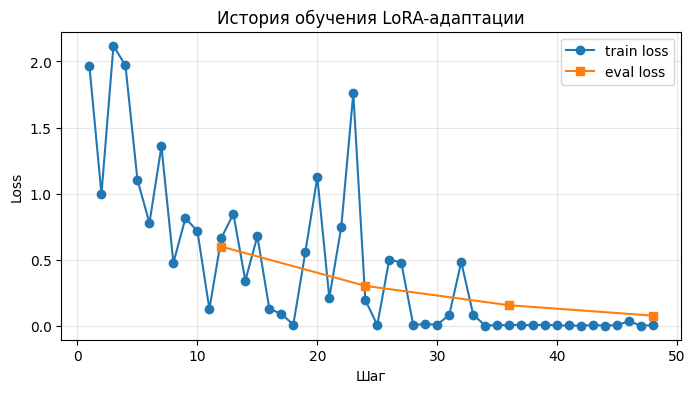

In [22]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(20))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения LoRA-адаптации")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 13. Оценка на `validation` и `test`

Теперь запускаем **тот же самый генеративный инференс**,  
но уже для адаптированной модели, и сравниваем его с baseline.

Именно здесь видно главное:  
улучшилась ли модель не в абстрактных внутренних лоссах, а в **реальной прикладной постановке**.

In [23]:
adapted_val_df, adapted_val_metrics = evaluate_model(model, val_df.reset_index(drop=True), "validation")
adapted_test_df, adapted_test_metrics = evaluate_model(model, test_df.reset_index(drop=True), "test")

comparison_metrics_df = pd.DataFrame(
    [
        {"stage": "base_model", "split": "validation", **baseline_val_metrics},
        {"stage": "base_model", "split": "test", **baseline_test_metrics},
        {"stage": "lora_adapted", "split": "validation", **adapted_val_metrics},
        {"stage": "lora_adapted", "split": "test", **adapted_test_metrics},
    ]
)

display(comparison_metrics_df)

,stage,split,accuracy,macro_f1,parsed_ratio
0,base_model,validation,0.250,0.1000,1.0
1,base_model,test,0.250,0.1000,1.0
2,lora_adapted,validation,0.875,0.8667,1.0
3,lora_adapted,test,0.875,0.8667,1.0


In [24]:
# Сравним ответы по validation-набору построчно.
val_compare_df = baseline_val_df.merge(
    adapted_val_df[["text", "predicted_label", "raw_answer", "is_correct"]],
    on="text",
    suffixes=("_base", "_lora"),
)

display(val_compare_df)

,split,text,target_label,predicted_label_base,raw_answer_base,is_correct_base,predicted_label_lora,raw_answer_lora,is_correct_lora
0,validation,После входа в аккаунт приложение закрывается без сообщения об ошибке.,bug,feature,feature,False,bug,bug,True
1,validation,"Почему уведомления приходят только на почту, а в интерфейсе их не видно?",question,feature,feature,False,question,question,True
2,validation,Можно ли ограничить доступ к проекту только одной команде?,question,feature,feature,False,feature,feature,False
3,validation,Хочется видеть историю изменений по каждой заявке.,feature,feature,feature,True,feature,feature,True
4,validation,"Спасибо, новый интерфейс стал заметно понятнее и быстрее.",praise,feature,feature,False,praise,praise,True
5,validation,Стоит реализовать пакетное редактирование статусов у нескольких задач.,feature,feature,feature,True,feature,feature,True
6,validation,"При попытке сменить пароль система пишет, что токен недействителен.",bug,feature,feature,False,bug,bug,True
7,validation,Хорошая доработка: стало меньше лишних кликов при работе с заказами.,praise,feature,feature,False,praise,praise,True


In [25]:
# Подробный отчёт по test-набору для адаптированной модели.
y_true = adapted_test_df["target_label"].tolist()
y_pred = [pred if pred is not None else "UNPARSED" for pred in adapted_test_df["predicted_label"]]

print(classification_report(y_true, y_pred, labels=ALLOWED_LABELS, zero_division=0))
display(adapted_test_df)

              precision    recall  f1-score   support

         bug       1.00      1.00      1.00         2
     feature       0.67      1.00      0.80         2
    question       1.00      1.00      1.00         2
      praise       1.00      0.50      0.67         2

    accuracy                           0.88         8
   macro avg       0.92      0.88      0.87         8
weighted avg       0.92      0.88      0.87         8



,split,text,target_label,predicted_label,raw_answer,is_correct
0,test,"Очень удобно, что теперь все отчёты собраны в одном разделе.",praise,feature,feature,False
1,test,Где переключается часовой пояс для отчётов и уведомлений?,question,question,question,True
2,test,"Уведомления отмечаются как прочитанные сами по себе, хотя я их не открывал.",bug,bug,bug,True
3,test,Сделайте выгрузку отчётов сразу в PDF и Excel.,feature,feature,feature,True
4,test,После обновления не сохраняются изменения в карточке клиента.,bug,bug,bug,True
5,test,"Классно, что экспорт теперь работает почти мгновенно.",praise,praise,praise,True
6,test,Нужен фильтр по периоду и по ответственному сотруднику.,feature,feature,feature,True
7,test,Есть ли в сервисе API для получения списка заказов?,question,question,question,True


## 14. Проверка адаптированной модели на новых текстах

После этого полезно проверить модель на **новых примерах**, которых не было в датасете.

Здесь нас интересуют два аспекта:

1. умеет ли модель воспроизводить нужный формат ответа;
2. насколько разумно она обобщает на похожие, но не идентичные формулировки.

In [26]:
new_texts = [
    "После последнего релиза отчёт формируется, но скачать его невозможно.",
    "Добавьте возможность скрывать неактуальные проекты из общего списка.",
    "Подскажите, есть ли ограничение на количество пользователей в одной группе?",
    "Спасибо, теперь навигация по разделам стала намного понятнее.",
    "Вроде всё работает, но страница аналитики иногда открывается слишком медленно.",
]

new_rows = []
for text in new_texts:
    pred_label, raw_answer = generate_label(model, text)
    new_rows.append(
        {
            "text": text,
            "predicted_label": pred_label,
            "raw_answer": raw_answer,
        }
    )

new_predictions_df = pd.DataFrame(new_rows)
display(new_predictions_df)

,text,predicted_label,raw_answer
0,"После последнего релиза отчёт формируется, но скачать его невозможно.",bug,bug
1,Добавьте возможность скрывать неактуальные проекты из общего списка.,feature,feature
2,"Подскажите, есть ли ограничение на количество пользователей в одной группе?",question,question
3,"Спасибо, теперь навигация по разделам стала намного понятнее.",praise,praise
4,"Вроде всё работает, но страница аналитики иногда открывается слишком медленно.",bug,bug


## 15. Разбор ошибок модели

Даже после адаптации ошибки обычно остаются.  
В учебном сценарии полезно разделить их хотя бы на несколько типов:

- **не распарсился формат** (`predicted_label = None`);
- **перепутаны близкие классы**, например `bug` и `question`;
- **пограничный кейс**: в сообщении одновременно есть и вопрос, и признак проблемы;
- **слишком маленький датасет**, из-за чего модель не видела достаточно разнообразных примеров.

Ниже выведем только проблемные примеры.

In [27]:
error_df = adapted_test_df[
    adapted_test_df["predicted_label"].isna() | (~adapted_test_df["is_correct"])
].copy()

if len(error_df) == 0:
    print("На текущем test-наборе ошибок не найдено.")
else:
    display(error_df)

,split,text,target_label,predicted_label,raw_answer,is_correct
0,test,"Очень удобно, что теперь все отчёты собраны в одном разделе.",praise,feature,feature,False


## 16. Что влияет на качество и стоимость адаптации

На практике на результат LoRA-адаптации влияют сразу несколько факторов:

1. **Качество и объём датасета.**  
   Если примеров мало и они однотипны, модель плохо обобщает.

2. **Формат instruction-примеров.**  
   То, как именно сформулирован `system` и `user` prompt, влияет на поведение не меньше, чем сами метки.

3. **Параметры LoRA.**  
   `r`, `lora_alpha`, `lora_dropout`, выбор `target_modules`.

4. **Базовая модель.**  
   Более сильная instruct-модель обычно лучше стартует даже до адаптации.

5. **Режим загрузки и ресурсы.**  
   4-bit / 8-bit экономят память, но добавляют ограничения и иногда усложняют отладку.

6. **Количество эпох и learning rate.**  
   На маленьком датасете очень легко переобучиться.

В инженерном смысле LoRA полезна тогда, когда:

- prompt-only режима уже недостаточно;
- полное дообучение слишком дорого;
- хочется получить **компактную адаптацию** под конкретную прикладную задачу.

## 17. Итоги

1. **LLM можно адаптировать под прикладную задачу без полного fine-tuning всех весов.**
2. **PEFT / LoRA позволяет обучать только небольшую долю параметров модели.**
3. **Для causal LM instruction tuning удобно строить пары `prompt → label` через chat-template.**
4. **При подготовке `labels` важно маскировать токены prompt-а, чтобы модель училась именно на ответе ассистента.**
5. **Сравнение baseline и LoRA-модели нужно делать через реальный генеративный инференс, а не только по loss.**
6. **Даже на маленьком учебном датасете видно, как LoRA делает поведение модели более специализированным.**

## Задания для самостоятельной работы

1. Увеличьте датасет ещё минимум на 20 примеров и проверьте, как меняются `accuracy` и `macro_f1`.
2. Попробуйте изменить `SYSTEM_PROMPT` и шаблон `build_user_prompt`, не меняя сам датасет, и посмотрите, влияет ли это на качество после адаптации.
3. Сравните несколько конфигураций LoRA: например, `r=4`, `r=8`, `r=16`.
4. Попробуйте обучать адаптеры только в attention-слоях, а затем в attention + MLP, и сравните результат.
5. Возьмите другую компактную instruct-модель и повторите тот же pipeline.
6. Подготовьте материалы для следующего ноутбука, где будем сравнивать `zero-shot`, `few-shot` и `LoRA-adapted` подходы на одном и том же наборе текстов.